<a href="https://colab.research.google.com/github/iqbalyk/Miniproject-Data-Analyst/blob/main/MiniProject3_FTDA6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**MINI PROJECT FTDA 6**
##Case Study + Business Question Bank Mandiri

###**Konteks Bisnis**

Bank Mandiri ingin mendeteksi anomali atau transaksi outlier pada segmen nasabah prioritas untuk **meningkatkan pengawasan
risiko, mencegah fraud, dan memberikan penanganan personal pada nasabah bernilai tinggi.**  Dengan data transaksi
high-value, peserta diminta mengidentifikasi outlier serta memprofilkan nasabahnya.

###**Tujuan Analisis:**

Menemukan transaksi tidak wajar (outlier) dan memahami karakteristik nasabah high-value di berbagai wilayah.

##**Pertanyaan yang Ingin Dijawab:**
1. Siapa saja nasabah dengan transaksi bernilai paling tinggi?

2. Produk dan channel apa yang paling sering digunakan oleh nasabah prioritas?

3. Di cabang mana terjadi transaksi dengan nilai paling tinggi?

4. Bagaimana memvisualisasikan distribusi transaksi dan mendeteksi outlier dengan box plot?

5. Apa profil demografi nasabah yang sering melakukan transaksi besar?


##**Menggabungkan 2 file menggunakan excel**

1. Pembersihan Data Transaction dan Customer menggunakan Power Query
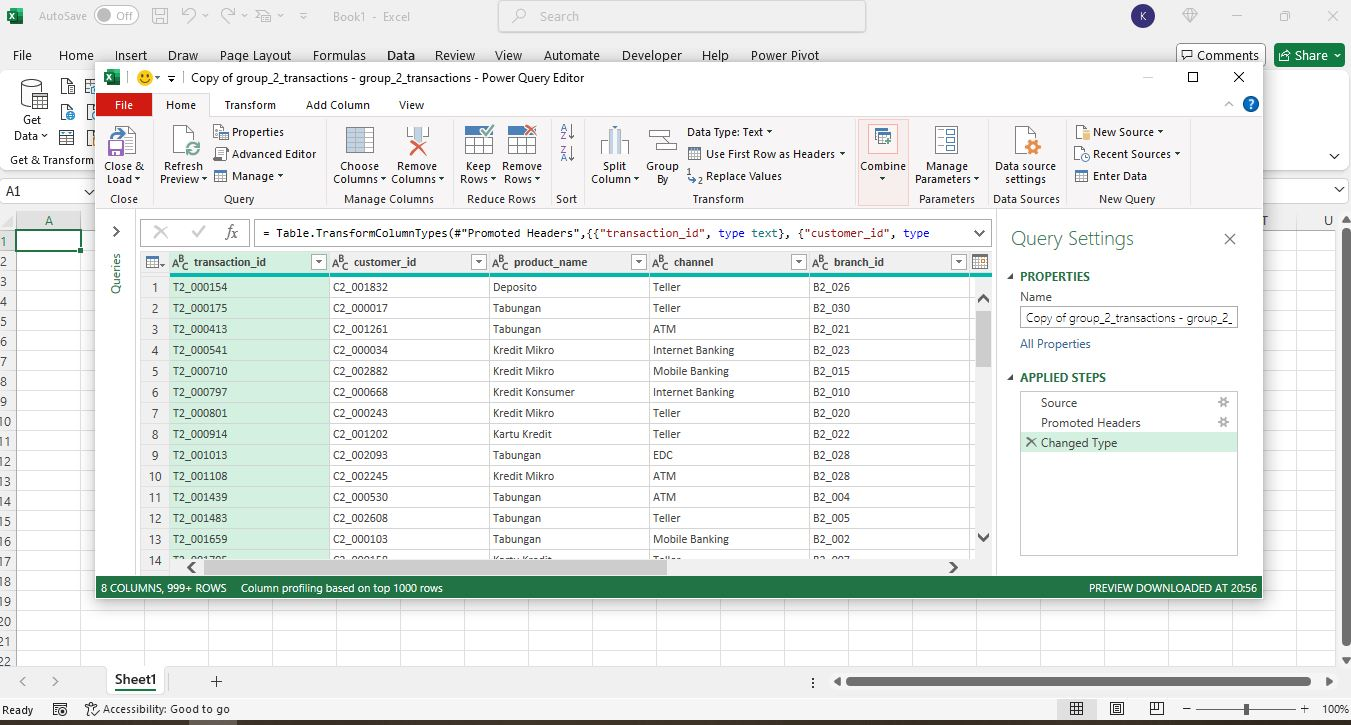

2. Merge 2 Data Model

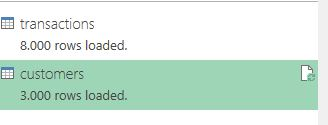

3. Merge Left Outer Transaction dan Customer

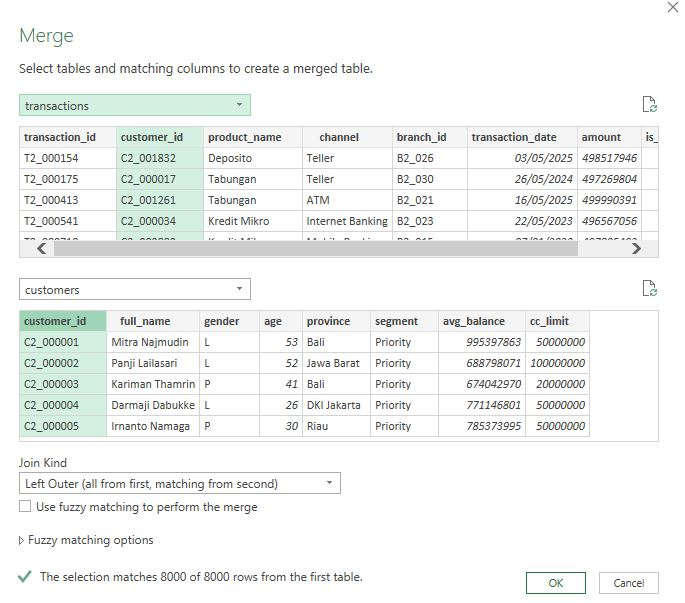

##**Ekspor ke CSV**

In [ ]:
#import data csv TransactionCustomer
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

df = pd.read_csv('https://raw.githubusercontent.com/iqbalyk/Miniproject-Digital-Skola/refs/heads/main/DatasetMiniproject3.csv', delimiter=';', engine='python')

# Change data type
cols_date = ['transaction_date']
for col in cols_date:
    df[col] = pd.to_datetime(df[col])

display(df.info())
df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   transaction_id    8000 non-null   object        
 1   customer_id       8000 non-null   object        
 2   full_name         8000 non-null   object        
 3   product_name      8000 non-null   object        
 4   channel           8000 non-null   object        
 5   branch_id         8000 non-null   object        
 6   province          8000 non-null   object        
 7   transaction_date  8000 non-null   datetime64[ns]
 8   amount            8000 non-null   int64         
 9   is_outlier        8000 non-null   bool          
 10  gender            8000 non-null   object        
 11  age               8000 non-null   int64         
 12  segment           8000 non-null   object        
 13  avg_balance       8000 non-null   int64         
 14  cc_limit          8000 n

None

,transaction_id,customer_id,full_name,product_name,channel,branch_id,province,transaction_date,amount,is_outlier,gender,age,segment,avg_balance,cc_limit
0,T2_000154,C2_001832,"Bahuwarna Astuti, S.Farm",Deposito,Teller,B2_026,Riau,2025-05-03,498517946,True,L,44,Priority,650620539,50000000
1,T2_002049,C2_001832,"Bahuwarna Astuti, S.Farm",Kredit Konsumer,ATM,B2_001,Riau,2023-12-06,339181496,False,L,44,Priority,650620539,50000000
2,T2_002252,C2_001832,"Bahuwarna Astuti, S.Farm",Kredit Mikro,EDC,B2_006,Riau,2023-03-21,219098155,False,L,44,Priority,650620539,50000000
3,T2_000175,C2_000017,Elisa Pratiwi,Tabungan,Teller,B2_030,Sulawesi Selatan,2024-05-26,497269804,True,L,56,Priority,670296648,100000000
4,T2_001910,C2_000002,Panji Lailasari,Kredit Mikro,ATM,B2_003,Jawa Barat,2024-02-25,90200030,False,L,52,Priority,688798071,100000000


In [ ]:
def simple_pivot_table(input_df, ind, val, agg):

  data = input_df.copy()

  pivot_a1 = pd.pivot_table(data, index=ind, values=val, aggfunc=agg).reset_index()
  pivot_a1 = pivot_a1.sort_values(by=val, ascending=False)
  return pivot_a1

def format_amount(amount):
    if amount >= 1_000_000_000:
        return f'{amount / 1_000_000_000:.2f} B'
    elif amount >= 1_000_000:
        return f'{amount / 1_000_000:.2f} M'
    else:
        return f'{amount:.2f}'

def bar_chart(input_df, x_axis, y_axis, xlabel, ylabel, title):

  ax= sns.barplot(data=input_df.head(5), x=x_axis, y=y_axis, color='yellow')
  plt.xlabel(xlabel)
  plt.xticks(rotation=45, ha='right')
  plt.ylabel(ylabel)
  plt.title(title)


  # Add Data Labels
  for container in ax.containers:
      ax.bar_label(container, fmt=lambda x: format_amount(x))

def bar_plot(input_df, x_axis, y_axis, hue, estimator, warna, legend, title):

    data4 = input_df.copy()

    ax2 = sns.barplot(data4, x=x_axis, y=y_axis, hue=hue,
                      estimator=estimator, palette=warna, legend=legend)
    plt.title(title)

    # Add Data Labels
    for container in ax2.containers:
        ax2.bar_label(container, fmt=lambda x: format_amount(x))




Q1. Who are the customers with the highest value transactions?

#Answer:

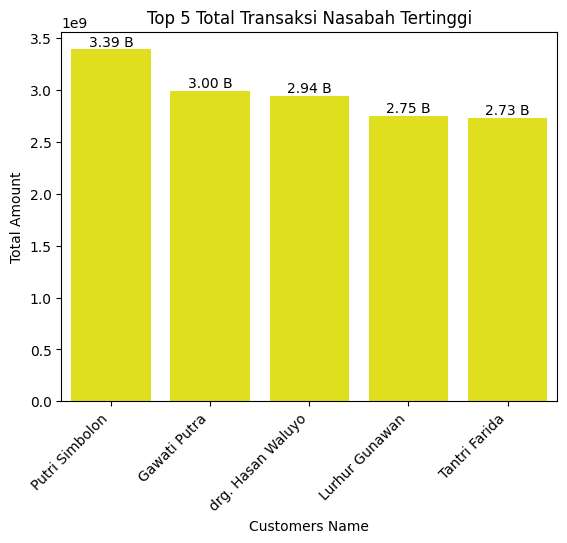

In [ ]:
q1= df.copy()

pivot_a1 = simple_pivot_table(df, ind='full_name', val='amount', agg='sum')
bar_chart(pivot_a1, x_axis='full_name' , y_axis='amount' , title='Top 5 Total Transaksi Nasabah Tertinggi', xlabel= 'Customers Name', ylabel= 'Total Amount')

Q2. What products and channels do priority customers use most frequently?

#Answer:

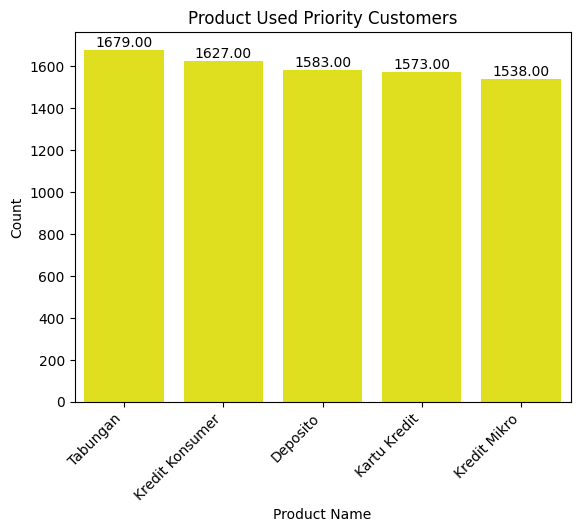

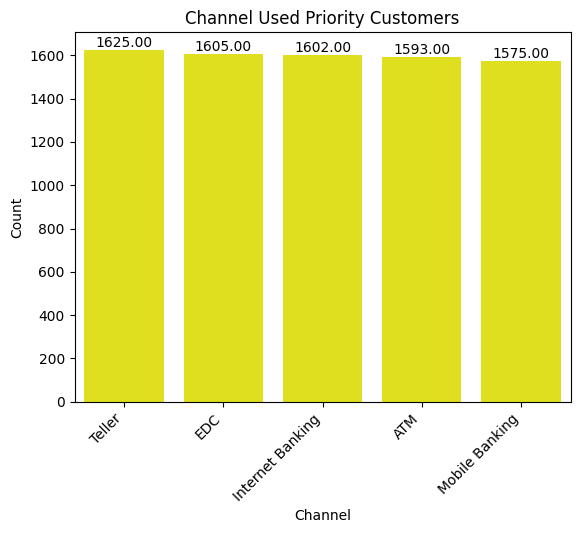

In [ ]:
# Filter for priority customers
priority_customers_df = df[df['segment'] == 'Priority'].copy()

# Count the occurrences of each product
product_counts = priority_customers_df['product_name'].value_counts().reset_index(name='count')
product_counts = product_counts.rename(columns={'index': 'product_name'})

# Count the occurrences of each channel
channel_counts = priority_customers_df['channel'].value_counts().reset_index(name='count')
channel_counts = channel_counts.rename(columns={'index': 'channel'})

# Visualize product counts
bar_chart(product_counts, x_axis='product_name', y_axis='count', xlabel='Product Name', ylabel='Count', title='Product Used Priority Customers')
plt.show()

# Visualize channel counts
bar_chart(channel_counts, x_axis='channel', y_axis='count', xlabel='Channel', ylabel='Count', title='Channel Used Priority Customers')
plt.show()

Q3. Which branch did the highest value transactions occur?

#Answer:

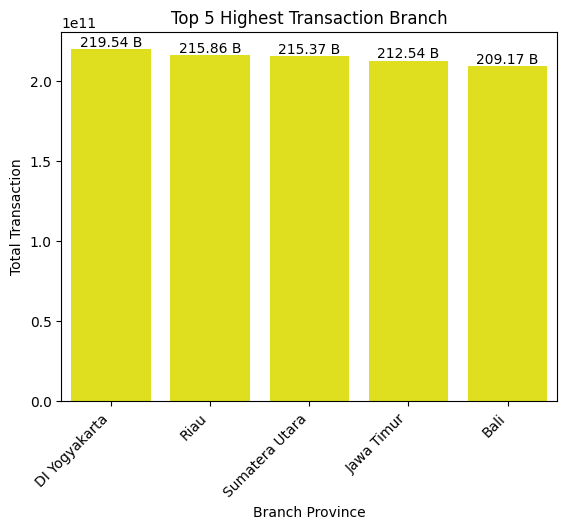

In [ ]:
pivot_a1 = simple_pivot_table(df, ind='province', val='amount', agg='sum')
bar_chart(pivot_a1, x_axis='province' , y_axis='amount' , title='Top 5 Highest Transaction Branch', xlabel= 'Branch Province', ylabel= 'Total Transaction')

Q4. How to visualize transaction distribution and detect outliers with box plots?

#Answer:

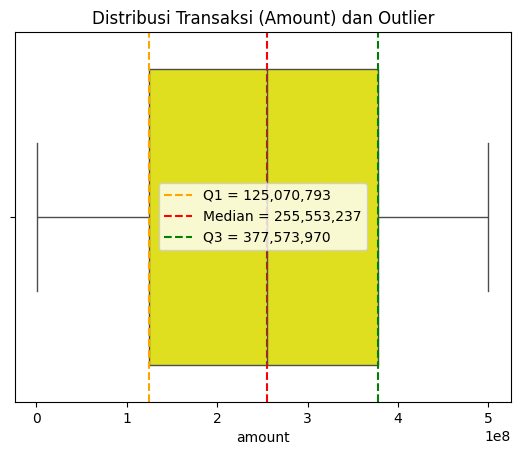

In [ ]:
sns.boxplot(x=df["amount"], color="yellow")
plt.title("Distribusi Transaksi (Amount) dan Outlier")

plt.axvline(Q1, color='orange', linestyle='--', label=f"Q1 = {Q1:,.0f}")
plt.axvline(df["amount"].median(), color='red', linestyle='--', label=f"Median = {df['amount'].median():,.0f}")
plt.axvline(Q3, color='green', linestyle='--', label=f"Q3 = {Q3:,.0f}")
plt.legend()
plt.show()


Q4. What is the demographic profile of consumers who frequently make large transactions?
#Answer:

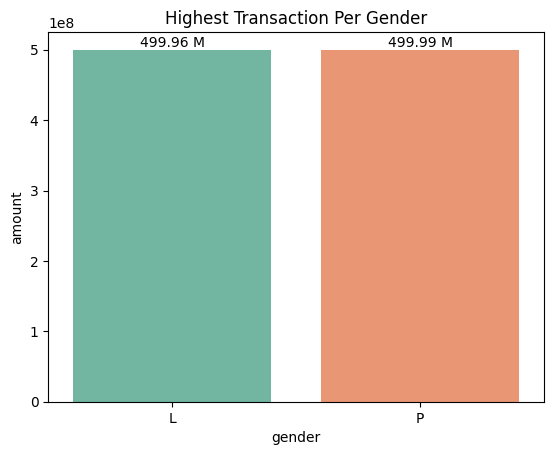

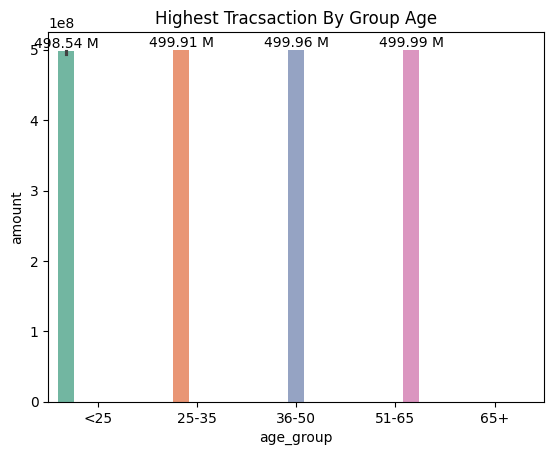

In [ ]:
# What is the demographic profile of consumers who frequently make large transactions?

df.groupby("gender", observed=False)["amount"].max().sort_values(ascending=True)
df.groupby("age_group", observed=False)["amount"].max().sort_values(ascending=True)

# Gender
bar_plot(df, x_axis='gender', y_axis='amount', hue='gender', estimator='max', warna='Set2', legend=False, title='Highest Transaction Per Gender')
plt.show()

# Age group
bar_plot(df, x_axis='age_group', y_axis='amount', hue='age_group', estimator='max', warna='Set2', legend=False, title='Highest Tracsaction By Group Age')
plt.show()